Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
  PHASE 1: Feature Extraction (Frozen VGG16)
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 164s 909ms/step - accuracy: 0.7347 - loss: 0.5365 - val_accuracy: 0.5000 - val_loss: 0.6843 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 739ms/step - accuracy: 0.7964 - loss: 0.4240 - val_accuracy: 0.5625 - val_loss: 0.6897 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 120s 738ms/step - accuracy: 0.8393 - loss: 0.3594 - val_accuracy: 0.6875 - val_loss: 0.5728 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 120s 737ms/step - accuracy: 0.8639 - loss: 0.3204 - val_accuracy: 0.7500 - val_loss: 0.5731 - learning_rate: 1.0000e-04
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 119s 732ms/step - accuracy

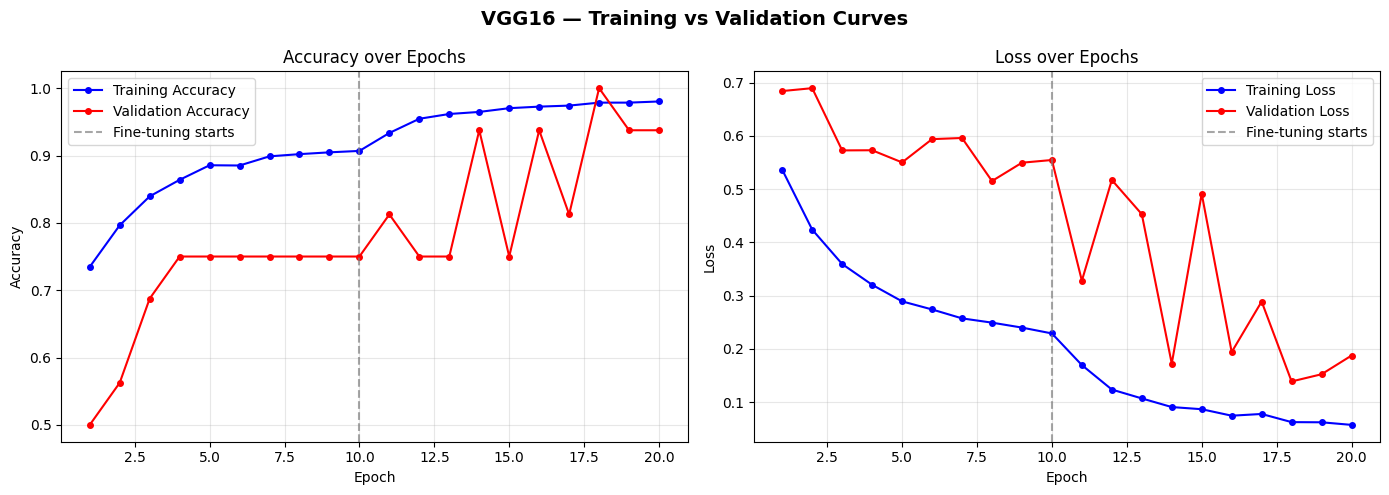

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 405ms/step

  VGG16 — FINAL TEST RESULTS
Accuracy:  91.51%
Precision: 90.41%
Recall:    96.67%
F1 Score:  93.43%

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.83      0.88       234
   PNEUMONIA       0.90      0.97      0.93       390

    accuracy                           0.92       624
   macro avg       0.92      0.90      0.91       624
weighted avg       0.92      0.92      0.91       624



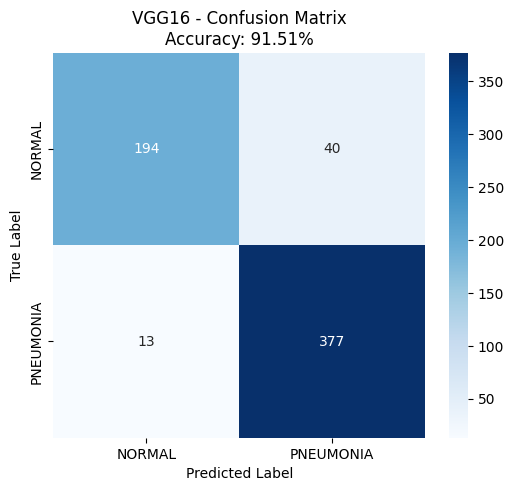

In [ ]:
import os
import numpy as np
import kagglehub
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, recall_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
DATA_DIR = os.path.join(path, "chest_xray")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1]
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "train"),
    target_size=(224, 224), batch_size=32, class_mode='binary'
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "val"),
    target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "test"),
    target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False
)

# ============================================
# PHASE 1: Feature Extraction
# ============================================
print("="*50)
print("  PHASE 1: Feature Extraction (Frozen VGG16)")
print("="*50)

base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

model = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop1 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr1 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

history1 = model.fit(
    train_gen, epochs=10, validation_data=val_gen,
    callbacks=[early_stop1, reduce_lr1]
)

# ============================================
# PHASE 2: Fine-Tuning
# ============================================
print("\n" + "="*50)
print("  PHASE 2: Fine-Tuning (Unfrozen Top Layers)")
print("="*50)

base.trainable = True
for layer in base.layers[:15]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr2 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

history2 = model.fit(
    train_gen, epochs=10, validation_data=val_gen,
    callbacks=[early_stop2, reduce_lr2]
)

print(f"\nPhase 1 completed: {len(history1.history['loss'])} epochs")
print(f"Phase 2 completed: {len(history2.history['loss'])} epochs")


acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']
epochs = range(1, len(acc) + 1)
tune_start = len(history1.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("VGG16 — Training vs Validation Curves", fontsize=14, fontweight='bold')

axes[0].plot(epochs, acc, 'b-o', ms=4, label='Training Accuracy')
axes[0].plot(epochs, val_acc, 'r-o', ms=4, label='Validation Accuracy')
axes[0].axvline(tune_start, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning starts')
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, loss, 'b-o', ms=4, label='Training Loss')
axes[1].plot(epochs, val_loss, 'r-o', ms=4, label='Validation Loss')
axes[1].axvline(tune_start, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning starts')
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("vgg16_training_curves.png", dpi=150)
plt.show()

test_gen.reset()
y_prob = model.predict(test_gen)
y_pred = (y_prob > 0.5).astype(int)
y_true = test_gen.classes

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\n" + "="*50)
print("  VGG16 — FINAL TEST RESULTS")
print("="*50)
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"])
plt.title(f"VGG16 - Confusion Matrix\nAccuracy: {accuracy*100:.2f}%")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.savefig("vgg16_confusion.png", dpi=150)
plt.show()